In [60]:
import rasterio
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

In [61]:
def load_sar_tiff(path):

    def _read(p):
        path_str = p.item().decode("utf-8")   # ✅ FINAL FIX

        with rasterio.open(path_str) as src:
            vv = src.read(1).astype(np.float32)
            vh = src.read(2).astype(np.float32)

        vv = np.clip(vv, -35.0, 5.0)
        vh = np.clip(vh, -40.0, 0.0)

        vv = (vv + 35.0) / 40.0
        vh = (vh + 40.0) / 40.0

        img = np.stack([vv, vh], axis=-1)

        img = tf.image.resize(img, (512, 512), method="bilinear").numpy()

        return img.astype(np.float32)

    img = tf.numpy_function(_read, [path], tf.float32)
    img.set_shape([512, 512, 2])
    return img

In [62]:
def fast_bradley(img, T=15, window_size=51):

    mean = cv2.blur(img.astype(np.float32), (window_size, window_size))
    threshold = mean * (1 - T/100)

    mask = np.zeros_like(img, dtype=np.uint8)
    mask[img < threshold] = 255   # detect dark oil

    return mask

In [63]:
def remove_small_components(mask, min_area=200):

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = np.zeros_like(mask)

    for i in range(1, num_labels):  # skip background
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned[labels == i] = 255

    return cleaned

In [64]:
def create_oil_mask(sar_tensor):

    sar_np = sar_tensor.numpy()  # (512,512,2)

    vv = sar_np[:, :, 0]
    vh = sar_np[:, :, 1]

    # 🔥 30:70 Combination
    combined = 0.3 * vv + 0.7 * vh

    # Convert to 8-bit
    combined = (combined * 255).astype(np.uint8)

    # Contrast enhancement (better than equalizeHist)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(combined)

    # Speckle reduction
    filtered = cv2.medianBlur(enhanced, 5)

    # Otsu threshold (detect dark)
    _, otsu_mask = cv2.threshold(
        filtered,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    otsu_mask = cv2.bitwise_not(otsu_mask)

    # Bradley threshold
    bradley_mask = fast_bradley(filtered, T=15, window_size=51)

    # Combine both
    # combined_mask = cv2.bitwise_or(otsu_mask, bradley_mask)
    combined_mask = cv2.bitwise_and(otsu_mask, bradley_mask)

    # Morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    final = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel)
    final = cv2.morphologyEx(final, cv2.MORPH_OPEN, kernel)

    # Remove tiny detections
    final = remove_small_components(final, min_area=200)

    return enhanced, final

In [71]:
tif_path = tf.constant("./Images/Oil/Images/00002.tif")

sar_img = load_sar_tiff(tif_path)
original, mask = create_oil_mask(sar_img)

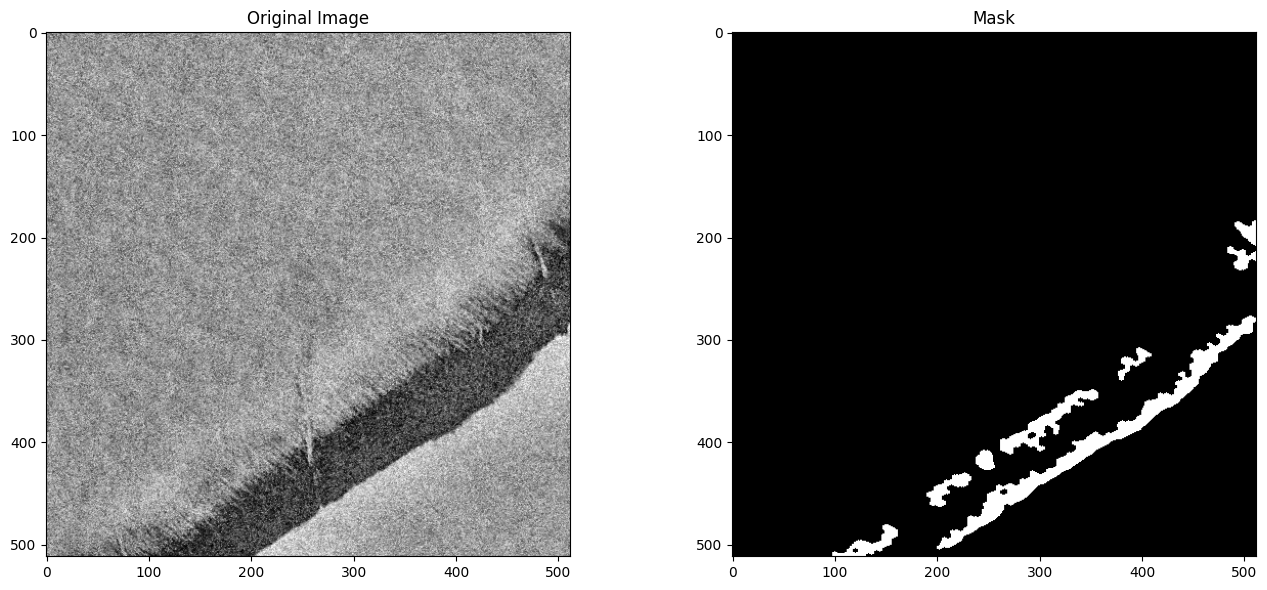

In [72]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(original, cmap='gray')

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask, cmap='gray')

plt.tight_layout()
plt.show()

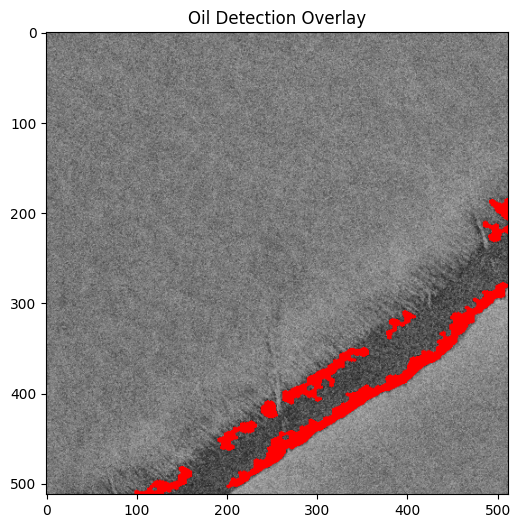

In [73]:
overlay = cv2.cvtColor(original, cv2.COLOR_GRAY2RGB)
overlay[mask == 255] = [255, 0, 0]

plt.figure(figsize=(6,6))
plt.title("Oil Detection Overlay")
plt.imshow(overlay)
plt.show()

In [96]:
import rasterio
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

In [97]:
def load_sar_tiff(path):

    def _read(p):
        path_str = p.item().decode("utf-8")

        with rasterio.open(path_str) as src:
            vv = src.read(1).astype(np.float32)
            vh = src.read(2).astype(np.float32)

        vv = np.clip(vv, -35.0, 5.0)
        vh = np.clip(vh, -40.0, 0.0)

        vv = (vv + 35.0) / 40.0
        vh = (vh + 40.0) / 40.0

        img = np.stack([vv, vh], axis=-1)

        img = tf.image.resize(img, (512, 512), method="bilinear").numpy()

        return img.astype(np.float32)

    img = tf.numpy_function(_read, [path], tf.float32)
    img.set_shape([512, 512, 2])
    return img

In [98]:
def filter_components(mask, min_area=300, max_area=30000, min_aspect_ratio=1.5):

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = np.zeros_like(mask)

    for i in range(1, num_labels):

        area = stats[i, cv2.CC_STAT_AREA]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]

        aspect_ratio = max(w, h) / (min(w, h) + 1e-6)

        if (area >= min_area and
            area <= max_area and
            aspect_ratio >= min_aspect_ratio):

            cleaned[labels == i] = 255

    return cleaned

In [99]:
def texture_filtered_detection(img):

    img = img.astype(np.float32)

    # 1️⃣ Dark anomaly detection
    local_mean = cv2.GaussianBlur(img, (51, 51), 0)
    diff = local_mean - img

    # Adaptive k based on image contrast
    contrast = np.std(img)
    k = 0.8 if contrast < 25 else 1.0

    dark_thresh = np.mean(diff) + k * np.std(diff)

    dark_mask = np.zeros_like(img, dtype=np.uint8)
    dark_mask[diff > dark_thresh] = 255

    # 2️⃣ Texture filtering
    mean_sq = cv2.GaussianBlur(img**2, (31, 31), 0)
    sq_mean = cv2.GaussianBlur(img, (31, 31), 0) ** 2
    variance = mean_sq - sq_mean

    # Adaptive percentile
    texture_thresh = np.percentile(variance, 60)

    smooth_mask = np.zeros_like(img, dtype=np.uint8)
    smooth_mask[variance < texture_thresh] = 255

    # Combine
    final_mask = cv2.bitwise_and(dark_mask, smooth_mask)

    return final_mask

In [100]:
def create_oil_mask(sar_tensor):

    sar_np = sar_tensor.numpy()

    vv = sar_np[:, :, 0]
    vh = sar_np[:, :, 1]

    # 🔥 30:70 VV:VH combination
    combined = vh
    combined = (combined * 255).astype(np.uint8)

    # Mild contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8,8))
    enhanced = clahe.apply(combined)

    # Speckle reduction
    filtered = cv2.medianBlur(enhanced, 5)

    # Texture-aware detection
    combined_mask = texture_filtered_detection(filtered)

    # Morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    final = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel)
    final = cv2.morphologyEx(final, cv2.MORPH_OPEN, kernel)

    # Shape filtering
    final = filter_components(final,
                              min_area=300,
                              max_area=30000,
                              min_aspect_ratio=1.5)

    return enhanced, final

In [101]:
tif_path = tf.constant("./Images/Oil/Images/00001.tif")

sar_img = load_sar_tiff(tif_path)
original, mask = create_oil_mask(sar_img)

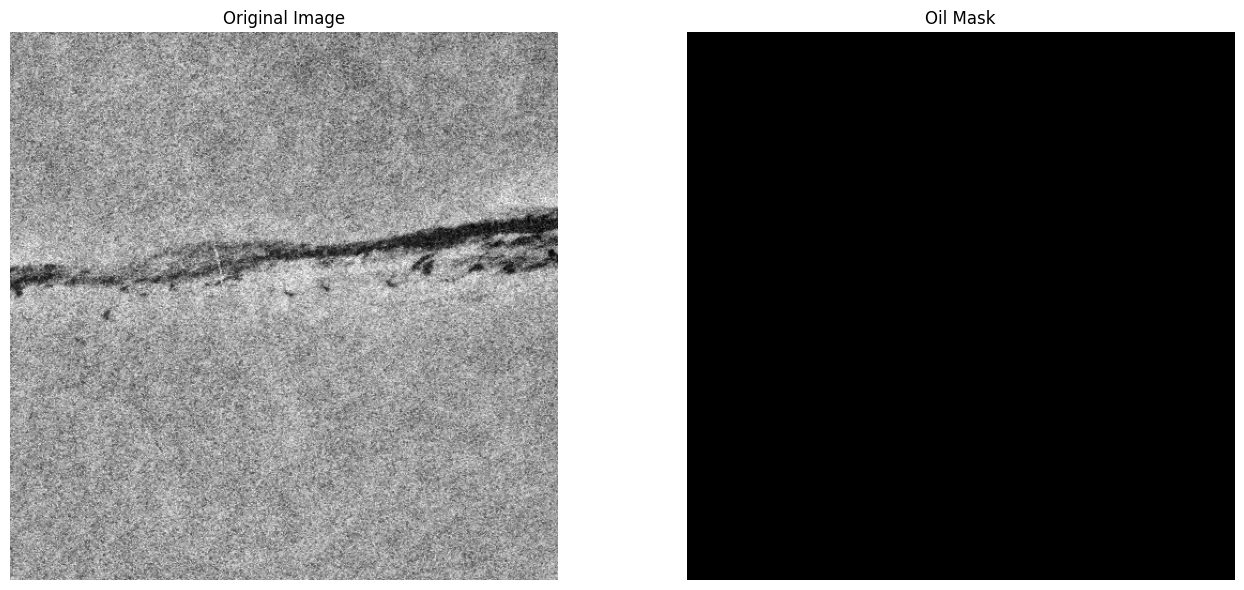

In [102]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(original, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Oil Mask")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()